In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

In [32]:
import sys
sys.stdout = open('training_log.txt', 'w')

In [3]:
class LoRALinear(nn.Module):
    def __init__(self, linear_layer, r=8, alpha=16):
        super().__init__()
        self.linear = linear_layer
        self.r = r
        self.alpha = alpha
        
        in_dim = linear_layer.in_features
        out_dim = linear_layer.out_features

        self.linear.weight.requires_grad = False
        self.A = nn.Parameter(torch.randn(r, in_dim) * 0.01)
        self.B = nn.Parameter(torch.zeros(out_dim, r))

        self.scaling = alpha / r

    def forward(self, x):
        original = self.linear(x)
        lora_update = (x @ self.A.T) @ self.B.T
        return original + self.scaling * lora_update

In [4]:
class DoraLayer(nn.Module):
    def __init__(self, linear_layer, r=8, alpha=16):
        super().__init__()
        self.base_layer = linear_layer
        out_features, in_features = linear_layer.weight.shape

        self.lora_A = nn.Linear(in_features, r, bias=False)
        self.lora_B = nn.Linear(r, out_features, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        self.scaling = alpha / r

        with torch.no_grad():
            m = torch.linalg.norm(self.base_layer.weight, dim=1, keepdim=True)
        self.m = nn.Parameter(m)

    def forward(self, x):
        delta_v = (self.lora_B.weight @ self.lora_A.weight) * self.scaling
        v_new = self.base_layer.weight + delta_v
        norm_scale = self.m / torch.linalg.norm(v_new, dim=1, keepdim=True).detach()
        base_output = nn.functional.linear(x, self.base_layer.weight)
        lora_output = self.lora_B(self.lora_A(x)) * self.scaling
        result = norm_scale.view(1,1,-1) * (base_output + lora_output)
        if self.base_layer.bias is not None:
            result += self.base_layer.bias
        return result

In [5]:
def inject_lora_bert(model, r=8, alpha=16, target_modules=["query", "value"]):
    for param in model.parameters():
        param.requires_grad = False
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any(key in name for key in target_modules):
                parent_name, _, child_name = name.rpartition(".")
                parent = model.get_submodule(parent_name)
                setattr(parent, child_name, LoRALinear(module, r=r, alpha=alpha)
                )
    return model

In [6]:
def inject_dora_bert(model, r=8, alpha=16, target_modules=["query", "value"]):
    for param in model.parameters():
        param.requires_grad = False
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any(key in name for key in target_modules):
                parent_name, _, child_name = name.rpartition(".")
                parent = model.get_submodule(parent_name)
                setattr(parent, child_name, DoraLayer(module, r=r, alpha=alpha))
    return model

In [ ]:
dataset = load_dataset("ag_news")

In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [26]:
train_small = dataset["train"].shuffle(seed=42).select(range(2000))
test_small  = dataset["test"].shuffle(seed=42).select(range(500))

In [2]:
def decompose(W0, W, eps=1e-8):
    # Magnitudes: absolute difference
    m0 = torch.linalg.norm(W0, dim=1) 
    m  = torch.linalg.norm(W, dim=1)
    delta_M = torch.abs(m - m0).mean().item()

    # Directions
    v0 = W0 / (m0.unsqueeze(1) + eps)
    v  = W / (m.unsqueeze(1) + eps)
    
    # Cosine distance
    cos_sim = torch.sum(v * v0, dim=1)
    
    # Delta D = Mean(1 - cos_sim)
    delta_D = (1 - cos_sim).mean().item()

    return delta_M, delta_D

In [11]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)
model = inject_dora_bert(model)

query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, (DoraLayer, LoRALinear)):
        query_layers.append((name, module))
query_layers = query_layers[:6]

W0_dict = {}
for name, layer in query_layers:
    if isinstance(layer, LoRALinear):
        W0_dict[name] = layer.linear.weight.detach().clone()
    elif isinstance(layer, DoraLayer):
        W0_dict[name] = layer.base_layer.weight.detach().clone()
    else:
        W0_dict[name] = layer.weight.detach().clone()

weights_history = {name: [] for name, _ in query_layers}

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_small, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

num_epochs = 4
model.train()
step = 0

print(f"Starting {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch["input_ids"]
        mask = batch["attention_mask"]
        labels = batch["label"]

        outputs = model(input_ids=inputs, attention_mask=mask, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        step += 1

    print(f"Epoch {epoch+1} complete.")
    
    for name, layer in query_layers:
        if isinstance(layer, LoRALinear):
            # W_eff = W0 + (B @ A) * scaling
            W_eff = layer.linear.weight + (layer.scaling * layer.B @ layer.A)
            weights_history[name].append(W_eff.detach().clone())
            
        elif isinstance(layer, DoraLayer):
            # W_eff = m * (V + delta_V) / ||V + delta_V||
            delta_v = (layer.lora_B.weight @ layer.lora_A.weight) * layer.scaling
            v_new = layer.base_layer.weight + delta_v
            v_norm = torch.linalg.norm(v_new, dim=1, keepdim=True)
            W_eff = layer.m * (v_new / (v_norm + 1e-8))
            weights_history[name].append(W_eff.detach().clone())
            
        else:
            weights_history[name].append(layer.weight.detach().clone())

    print(f"Average Loss for Epoch {epoch+1}: {epoch_loss/len(train_loader):.4f}")

Starting 4 epochs...
Epoch 1 complete.
Average Loss for Epoch 1: 1.4576
Epoch 2 complete.
Average Loss for Epoch 2: 1.3839
Epoch 3 complete.
Average Loss for Epoch 3: 1.3394
Epoch 4 complete.
Average Loss for Epoch 4: 1.2936


In [13]:
delta_records = {name: {"delta_M": [], "delta_D": []} for name, _ in query_layers}

for name, weight_list in weights_history.items():
    W0 = W0_dict[name]
    for W in weight_list:
        dM, dD = decompose(W0, W)
        delta_records[name]["delta_M"].append(dM)
        delta_records[name]["delta_D"].append(dD)

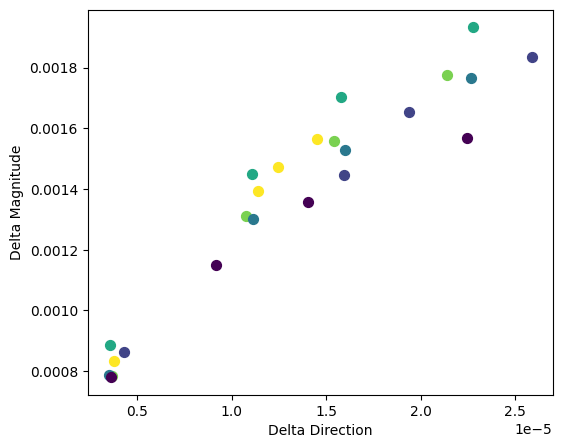

In [14]:
colors = plt.cm.viridis_r(np.linspace(0,1,len(query_layers)))

plt.figure(figsize=(6,5))
for i, (name, record) in enumerate(delta_records.items()):
    plt.scatter(record["delta_D"], record["delta_M"], label=name, color=colors[i], s=50)

plt.xlabel("Delta Direction")
plt.ylabel("Delta Magnitude")
##plt.legend()
plt.show()

In [18]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)
model = inject_lora_bert(model)

query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, (DoraLayer, LoRALinear)):
        query_layers.append((name, module))
query_layers = query_layers[:6]

W0_dict = {}
for name, layer in query_layers:
    if isinstance(layer, LoRALinear):
        W0_dict[name] = layer.linear.weight.detach().clone()
    elif isinstance(layer, DoraLayer):
        W0_dict[name] = layer.base_layer.weight.detach().clone()
    else:
        W0_dict[name] = layer.weight.detach().clone()

weights_history = {name: [] for name, _ in query_layers}

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_small, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

num_epochs = 4
model.train()
step = 0

print(f"Starting {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch["input_ids"]
        mask = batch["attention_mask"]
        labels = batch["label"]

        outputs = model(input_ids=inputs, attention_mask=mask, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        step += 1

    print(f"Epoch {epoch+1} complete.")
    
    for name, layer in query_layers:
        if isinstance(layer, LoRALinear):
            # W_eff = W0 + (B @ A) * scaling
            W_eff = layer.linear.weight + (layer.scaling * layer.B @ layer.A)
            weights_history[name].append(W_eff.detach().clone())
            
        elif isinstance(layer, DoraLayer):
            # W_eff = m * (V + delta_V) / ||V + delta_V||
            delta_v = (layer.lora_B.weight @ layer.lora_A.weight) * layer.scaling
            v_new = layer.base_layer.weight + delta_v
            v_norm = torch.linalg.norm(v_new, dim=1, keepdim=True)
            W_eff = layer.m * (v_new / (v_norm + 1e-8))
            weights_history[name].append(W_eff.detach().clone())
            
        else:
            weights_history[name].append(layer.weight.detach().clone())

    print(f"Average Loss for Epoch {epoch+1}: {epoch_loss/len(train_loader):.4f}")

Starting 4 epochs...
Epoch 1 complete.
Average Loss for Epoch 1: 1.4822
Epoch 2 complete.
Average Loss for Epoch 2: 1.4091
Epoch 3 complete.
Average Loss for Epoch 3: 1.3133
Epoch 4 complete.
Average Loss for Epoch 4: 1.2765


In [20]:
delta_records = {name: {"delta_M": [], "delta_D": []} for name, _ in query_layers}

for name, weight_list in weights_history.items():
    W0 = W0_dict[name]
    for W in weight_list:
        dM, dD = decompose(W0, W)
        delta_records[name]["delta_M"].append(dM)
        delta_records[name]["delta_D"].append(dD)

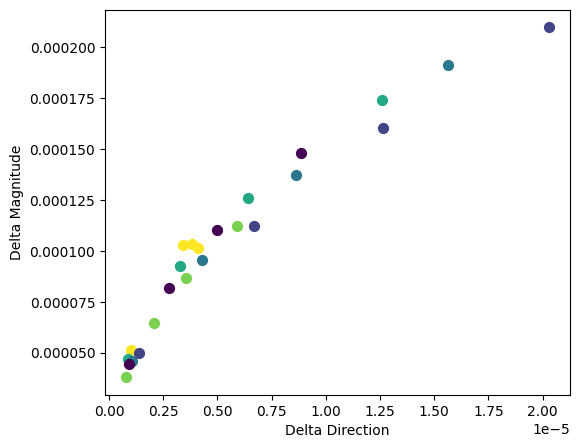

In [21]:
colors = plt.cm.viridis_r(np.linspace(0,1,len(query_layers)))

plt.figure(figsize=(6,5))
for i, (name, record) in enumerate(delta_records.items()):
    plt.scatter(record["delta_D"], record["delta_M"], label=name, color=colors[i], s=50)

plt.xlabel("Delta Direction")
plt.ylabel("Delta Magnitude")
##plt.legend()
plt.show()

In [40]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=4
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, (nn.Linear)):
        query_layers.append((name, module))
query_layers = query_layers[:6]

W0_dict = {}
for name, layer in query_layers:
    if isinstance(layer, LoRALinear):
        W0_dict[name] = layer.linear.weight.detach().clone()
    elif isinstance(layer, DoraLayer):
        W0_dict[name] = layer.base_layer.weight.detach().clone()
    else:
        W0_dict[name] = layer.weight.detach().clone()

weights_history = {name: [] for name, _ in query_layers}

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_small, batch_size=16, shuffle=True)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

num_epochs = 4
model.train()
step = 0

print(f"Starting {num_epochs} epochs...")

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader:
        inputs = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=inputs, attention_mask=mask, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        step += 1

    print(f"Epoch {epoch+1} complete.")
    
    for name, layer in query_layers:
        if isinstance(layer, LoRALinear):
            # W_eff = W0 + (B @ A) * scaling
            W_eff = layer.linear.weight + (layer.scaling * layer.B @ layer.A)
            weights_history[name].append(W_eff.detach().clone())
            
        elif isinstance(layer, DoraLayer):
            # W_eff = m * (V + delta_V) / ||V + delta_V||
            delta_v = (layer.lora_B.weight @ layer.lora_A.weight) * layer.scaling
            v_new = layer.base_layer.weight + delta_v
            v_norm = torch.linalg.norm(v_new, dim=1, keepdim=True)
            W_eff = layer.m * (v_new / (v_norm + 1e-8))
            weights_history[name].append(W_eff.detach().clone())
            
        else:
            weights_history[name].append(layer.weight.detach().clone())

    print(f"Average Loss for Epoch {epoch+1}: {epoch_loss/len(train_loader):.4f}")

In [50]:
delta_records = {name: {"delta_M": [], "delta_D": []} for name, _ in query_layers}

for name, weight_list in weights_history.items():
    W0 = W0_dict[name]
    for W in weight_list:
        dM, dD = decompose(W0, W)
        delta_records[name]["delta_M"].append(dM)
        delta_records[name]["delta_D"].append(dD)

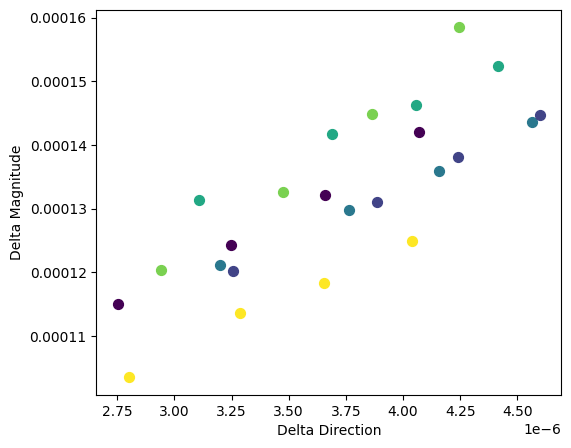

In [51]:
colors = plt.cm.viridis_r(np.linspace(0,1,len(query_layers)))

plt.figure(figsize=(6,5))
for i, (name, record) in enumerate(delta_records.items()):
    plt.scatter(record["delta_D"], record["delta_M"], label=name, color=colors[i], s=50)

plt.xlabel("Delta Direction")
plt.ylabel("Delta Magnitude")
##plt.legend()
plt.savefig("dora_analysis_plot.png")
print("Plot saved as dora_analysis_plot.png")
plt.show()

In [ ]:
sys.stdout.close()

In [3]:
dataset = load_dataset("glue", "mnli")

In [4]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["premise"], 
        example["hypothesis"], 
        truncation=True, 
        padding="max_length", 
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [13]:
train_small = dataset["train"].shuffle(seed=42).select(range(5000))

In [ ]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, nn.Linear):
        query_layers.append((name, module))
target_layers = query_layers[6:]

# Store initial weights
W0_dict = {name: layer.weight.detach().clone().to(device) for name, layer in target_layers}
delta_history = {name: {"m": [], "d": []} for name, _ in target_layers}

train_loader = DataLoader(train_small, batch_size=16, shuffle=True)
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

num_epochs = 4
model.train()

print(f"Starting training on device: {device}")

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader:
        inputs, mask, labels = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["label"].to(device)

        outputs = model(input_ids=inputs, attention_mask=mask, labels=labels)
        loss = outputs.loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} complete. Avg Loss: {epoch_loss/len(train_loader):.4f}")
    
    # Capture deltas after each epoch
    for name, layer in target_layers:
        W_current = layer.weight.detach()
        dm, dd = decompose(W0_dict[name], W_current)
        delta_history[name]["m"].append(dm)
        delta_history[name]["d"].append(dd)

plt.switch_backend('Agg')
plt.figure(figsize=(8, 6))

colors = plt.cm.plasma(np.linspace(0, 1, len(target_layers)))

for i, (name, record) in enumerate(delta_history.items()):
    # Plotting the 'Final' state (last epoch) as a larger point
    plt.scatter(record["d"], record["m"], color=colors[i], label=f"Layer {i+6}", s=100, edgecolors='black')
    plt.plot(record["d"], record["m"], color=colors[i], alpha=0.3)

plt.title("DoRA Replication: Magnitude vs Directional Update (MNLI)")
plt.xlabel("Directional Update (Delta D)")
plt.ylabel("Magnitude Update (Delta M)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("dora_analysis_plot1.png")

print("Analysis complete. Plot saved.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training on device: cpu
Epoch 1 complete. Avg Loss: 1.0951
Epoch 2 complete. Avg Loss: 1.0714
Epoch 3 complete. Avg Loss: 1.1021
Epoch 4 complete. Avg Loss: 1.1016
Analysis complete. Plot saved.
